Imports

In [2]:
import logging
import logging.config as log_config
from pathlib import Path
import json
import csv
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from PIL import Image

import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.FileHandler("evaluation.log"), logging.StreamHandler()],
)
logger = logging.getLogger(__name__)


Configuration

In [3]:
PROCESSED_ROOT = Path("../../data/processed/Stage3/combined")
INDEX_CSV = PROCESSED_ROOT / "index.csv" 

VAL_LABELS_JSON = Path("../../data/labels/Stage3/val.json")   # validate on val
TEST_LABELS_JSON = Path("../../data/labels/Stage3/test.json")  # later only, when frozen

# Model paths - update these to point to your best model
MODEL_PATH = Path("../../models/classifier/Stage3/modelV2.pt")

IMAGE_MODE = "rgb"    # "rgb" or "gray" (must match training)
IMAGE_SIZE = 256
BATCH_SIZE = 80
NUM_CLASSES = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)





Using device: cuda


Load index.csv

In [4]:
def read_index_csv(index_csv_path: Path):
    rows = []
    with open(index_csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(r)
    if not rows:
        raise ValueError(f"index.csv empty: {index_csv_path}")
    if "filepath" not in rows[0]:
        raise ValueError("index.csv must have a 'filepath' column")
    return rows

index_rows = read_index_csv(INDEX_CSV)
print("index rows:", len(index_rows))
print("example:", index_rows[0]["filepath"], "split:", index_rows[0].get("split"))


index rows: 2360
example: images/train/stage2__2026-01-21_15-43-51-512_aug00.png split: train


Load val labels

In [ ]:
def load_label_map(label_path: Path):
    if not label_path.exists():
        raise FileNotFoundError(f"Label file not found: {label_path}")

    with open(label_path, "r") as f:
        data = json.load(f)

    out = {}
    bad = []

    # -------------------------
    # Dict format: {filepath: class_id}
    # -------------------------
    if isinstance(data, dict):
        for k, v in data.items():
            k_norm = k.replace("\\", "/")
            out[k_norm] = int(v)
            out[Path(k_norm).name] = int(v)  # basename support
        return out

    
    if isinstance(data, list):
        for item in data:
            filepath = (item.get("image") or "").replace("\\", "/")
            if not filepath:
                bad.append(("MISSING_IMAGE_FIELD", item))
                continue

            fname = Path(filepath).name  # basename key too

            cluttered = int(item.get("cluttered", 0))
          

            # Your binary rule:
            # empty tray -> class 0
            # isolated items -> class 1
            if cluttered == 1:
                class_id = 0
            elif cluttered == 0:
                class_id = 1
            else:
                bad.append((filepath, cluttered))
                continue

            out[filepath] = class_id
            out[fname] = class_id  # now filename-only works

        if bad:
            print("Found inconsistent labels (showing up to 10):")
            for row in bad[:10]:
                print("  ", row)
            raise ValueError(f"Inconsistent labels for {len(bad)} samples in {label_path}")

        return out

    raise ValueError("Label JSON must be a dict or list")

print("VAL_LABELS_JSON:", VAL_LABELS_JSON.resolve())
val_label_map = load_label_map(VAL_LABELS_JSON)
print("Val labels loaded:", len(val_label_map))

VAL_LABELS_JSON: /home/ssy/Desktop/xray-gen-ai_Project/data/labels/Stage3/val.json
Val labels loaded: 470


In [6]:
def crop_to_tray_interior(img: Image.Image) -> Image.Image:
    w, h = img.size
    return img.crop((
        int(w * 0.2),
        int(h * 0.2),
        int(w * 0.8),
        int(h * 0.8),
    ))

Dataset(split-safe)

In [7]:
_MISS = object()

class ProcessedSplitDataset(Dataset):
    def __init__(self, index_rows, processed_root: Path, split: str, label_map: dict, transform=None):
        self.processed_root = processed_root
        self.split = split.lower().strip()
        self.transform = transform
        self.label_map = label_map

        rows = []
        for r in index_rows:
            fp = (r.get("filepath") or "").replace("\\", "/").strip()
            if not fp:
                continue
            row_split = (r.get("split") or "").strip().lower()
            if row_split == self.split:
                rows.append(r)

        if not rows:
            raise ValueError(f"No samples found for split='{self.split}'")

        self.filepaths, self.labels = [], []
        missing = []

        for r in rows:
            fp_norm = (r.get("filepath") or "").replace("\\", "/").strip()
            fname = Path(fp_norm).name

            keys = [fp_norm, f"images/{self.split}/{fname}", fname]
            label = _MISS
            for k in keys:
                label = self.label_map.get(k, _MISS)
                if label is not _MISS:
                    break

            if label is _MISS:
                missing.append(fp_norm)
                continue

            img_path = self.processed_root / fp_norm
            if not img_path.exists():
                raise FileNotFoundError(f"Missing file: {img_path}")

            self.filepaths.append(fp_norm)
            self.labels.append(int(label))

        if missing:
            print("Missing labels (first 20):")
            for m in missing[:20]:
                print(" ", m)
            raise KeyError(f"Missing labels for {len(missing)} samples.")

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        rel_path = self.filepaths[idx]
        img_path = self.processed_root / rel_path

        img = Image.open(img_path).convert("RGB" if IMAGE_MODE == "rgb" else "L")
        img = crop_to_tray_interior(img)

        if self.transform:
            img = self.transform(img)

        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, y, rel_path

In [8]:
import json
from pathlib import Path
from collections import Counter

p = Path("../../data/labels/Stage1/combined/val.json")
data = json.load(open(p, "r"))

# how many are filename-only (no slash)?
fn_only = [it["image"] for it in data if "/" not in it.get("image","")]
print("Filename-only label rows:", len(fn_only))
print("Examples:", fn_only[:5])

# show image field prefix distribution
prefixes = Counter([it["image"].split("/")[0] if "/" in it["image"] else "FILENAME_ONLY" for it in data])
print("Prefix counts:", prefixes)

Filename-only label rows: 0
Examples: []
Prefix counts: Counter({'images': 154})


Transforms + DataLoader

In [9]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

if IMAGE_MODE == "rgb":
    val_transform = T.Compose([
        T.Resize(int(IMAGE_SIZE * 1.10)),
        T.CenterCrop(IMAGE_SIZE),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    in_channels = 3
else:
    val_transform = T.Compose([
        T.Resize(int(IMAGE_SIZE * 1.10)),
        T.CenterCrop(IMAGE_SIZE),
        T.ToTensor(),
    ])
    in_channels = 1

val_ds = ProcessedSplitDataset(index_rows, PROCESSED_ROOT, "val", val_label_map, transform=val_transform)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Val label dist:", np.bincount(val_ds.labels, minlength=2))

print("Val samples:", len(val_ds))
x, y, p = next(iter(val_loader))
print("Batch shape:", x.shape, "| labels:", y[:5].tolist())

Val label dist: [125 110]
Val samples: 235


Batch shape: torch.Size([80, 3, 256, 256]) | labels: [1, 1, 1, 1, 1]


Define the same model architecture + load weights

In [ ]:


class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2, image_size=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, image_size, image_size)
            out = self.features(dummy)
            flat_dim = out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

class SimpleCNN_GAP(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = SimpleCNN_GAP(in_channels=in_channels, num_classes=NUM_CLASSES).to(device)

# =========================
# LOAD CHECKPOINT SAFELY
# =========================
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
missing, unexpected = model.load_state_dict(state, strict=False)

logger.info(f"Loaded model from: {MODEL_PATH}")
if missing:
    logger.warning(f"Missing keys (first 10): {missing[:10]}")
if unexpected:
    logger.warning(f"Unexpected keys (first 10): {unexpected[:10]}")

model.eval()
criterion = nn.CrossEntropyLoss()

print("Model loaded from:", MODEL_PATH)


2026-02-02 16:11:44,470 - INFO - Loaded model from: ../../models/classifier/Stage3/modelV2.pt


✅ Model loaded from: ../../models/classifier/Stage3/modelV2.pt


Run validation (loss, acc, predictions, probs)

In [11]:
all_y = []
all_pred = []
all_prob = []
all_paths = []
loss_sum = 0.0
n_total = 0

with torch.no_grad():

    for imgs, y, paths in val_loader:
        imgs = imgs.to(device)
        y = y.to(device)

        logits = model(imgs)
        loss = criterion(logits, y)

        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1)

        loss_sum += loss.item() * imgs.size(0)
        n_total += y.size(0)

        all_y.extend(y.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob.extend(probs.max(dim=1).values.cpu().numpy().tolist())
        all_paths.extend(list(paths))

val_loss = loss_sum / max(1, n_total)
val_acc = (np.array(all_pred) == np.array(all_y)).mean()

print(f"Val Loss: {val_loss:.4f}")
print(f"Val Acc : {val_acc:.4f}")

Val Loss: 0.0118
Val Acc : 1.0000


Average confidence: 0.9899
Min confidence: 0.5221
Max confidence: 1.0000
Median confidence: 0.9997


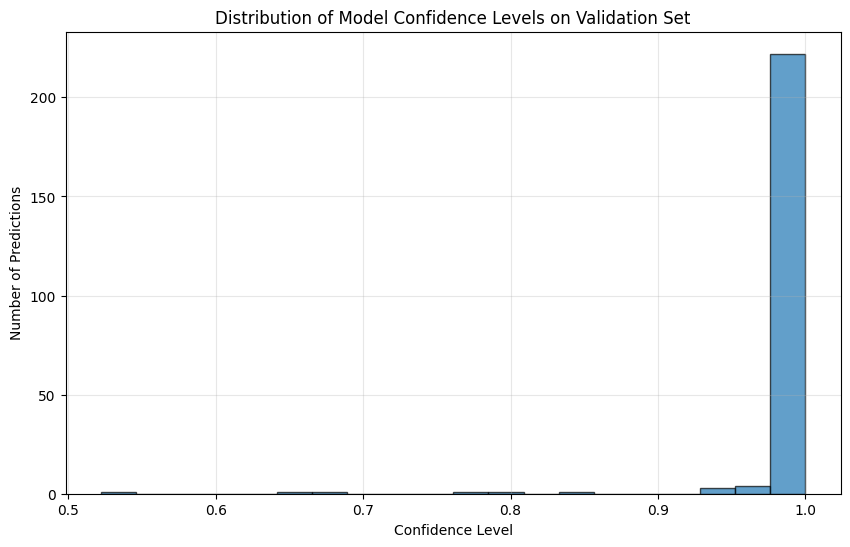

Average confidence for correct predictions: 0.9899
Average confidence for incorrect predictions: nan


/tmp/ipykernel_50719/1458861090.py:25: RuntimeWarning: Mean of empty slice.
  print(f"Average confidence for incorrect predictions: {incorrect_conf.mean():.4f}")
/home/ssy/Desktop/xray-gen-ai_Project/xray-gen-ai/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


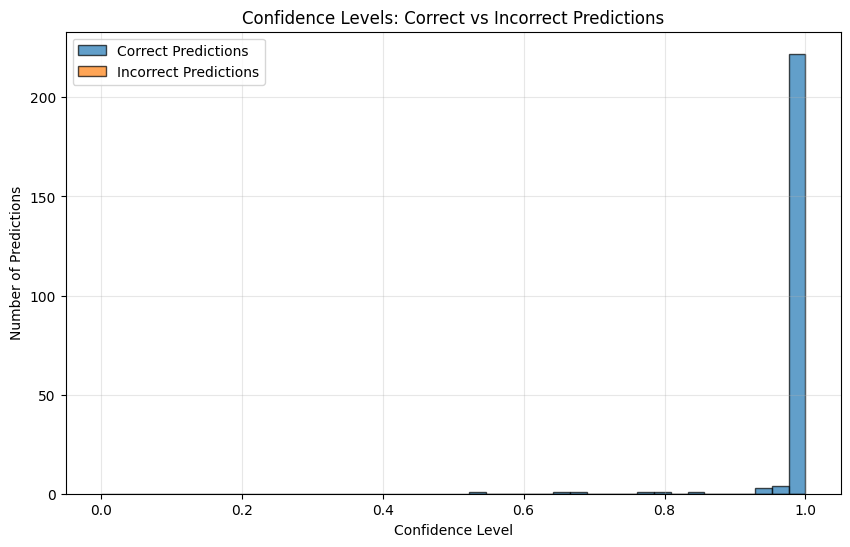

In [12]:
import matplotlib.pyplot as plt

# Analyze confidence levels
confidences = np.array(all_prob)
print(f"Average confidence: {confidences.mean():.4f}")
print(f"Min confidence: {confidences.min():.4f}")
print(f"Max confidence: {confidences.max():.4f}")
print(f"Median confidence: {np.median(confidences):.4f}")

# Plot histogram of confidence levels
plt.figure(figsize=(10, 6))
plt.hist(confidences, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Confidence Level')
plt.ylabel('Number of Predictions')
plt.title('Distribution of Model Confidence Levels on Validation Set')
plt.grid(True, alpha=0.3)
plt.show()

# Show confidence for correct vs incorrect predictions
correct_mask = np.array(all_pred) == np.array(all_y)
correct_conf = confidences[correct_mask]
incorrect_conf = confidences[~correct_mask]

print(f"Average confidence for correct predictions: {correct_conf.mean():.4f}")
print(f"Average confidence for incorrect predictions: {incorrect_conf.mean():.4f}")

# Plot comparison
plt.figure(figsize=(10, 6))
plt.hist(correct_conf, bins=20, alpha=0.7, label='Correct Predictions', edgecolor='black')
plt.hist(incorrect_conf, bins=20, alpha=0.7, label='Incorrect Predictions', edgecolor='black')
plt.xlabel('Confidence Level')
plt.ylabel('Number of Predictions')
plt.title('Confidence Levels: Correct vs Incorrect Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Confusion Matrix + Precision/Recall/F1 

In [13]:
def confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

cm = confusion_matrix(all_y, all_pred, NUM_CLASSES)
print("Confusion Matrix (rows=true, cols=pred):\n", cm)

# per-class precision/recall/f1
for c in range(NUM_CLASSES):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp

    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)

    print(f"Class {c}: Precision={prec:.3f} Recall={rec:.3f} F1={f1:.3f}")


total = cm.sum()
correct = np.trace(cm)          # sum of diagonal
wrong = total - correct

print(f"Total samples   : {total}")
print(f"Correct preds   : {correct}")
print(f"Wrong preds     : {wrong}")
print(f"Accuracy        : {correct / total:.4f}")


print("\nMisclassification breakdown (true → predicted):")
for t in range(NUM_CLASSES):
    for p in range(NUM_CLASSES):
        if t != p and cm[t, p] > 0:
            print(f"True class {t} predicted as {p}: {cm[t, p]}")

Confusion Matrix (rows=true, cols=pred):
 [[125   0]
 [  0 110]]
Class 0: Precision=1.000 Recall=1.000 F1=1.000
Class 1: Precision=1.000 Recall=1.000 F1=1.000
Total samples   : 235
Correct preds   : 235
Wrong preds     : 0
Accuracy        : 1.0000

Misclassification breakdown (true → predicted):


Grad-CAM target layer: Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


Val samples collected: 235

Picked samples:
correct_true0 -> {'path': 'images/val/stage3__2026-01-22_15-56-11-837_orig.png', 'true': 0, 'pred': 0, 'conf': 0.9999997615814209}
correct_true1 -> {'path': 'images/val/stage2__2026-01-21_16-45-07-556_orig.png', 'true': 1, 'pred': 1, 'conf': 0.9999905824661255}
wrong_true0 -> None
wrong_true1 -> None


/home/ssy/Desktop/xray-gen-ai_Project/xray-gen-ai/.venv/lib/python3.10/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


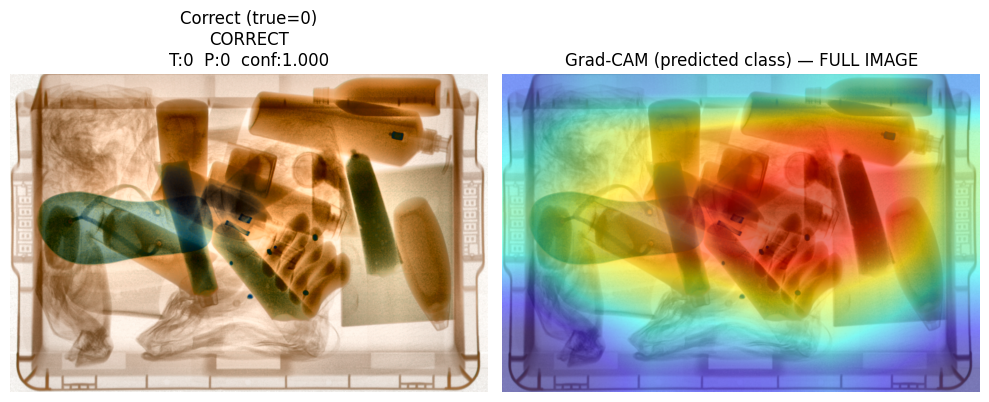


[Correct (true=0)] CORRECT
Path: images/val/stage3__2026-01-22_15-56-11-837_orig.png
True: 0 | Pred: 0 | Conf: 1.000


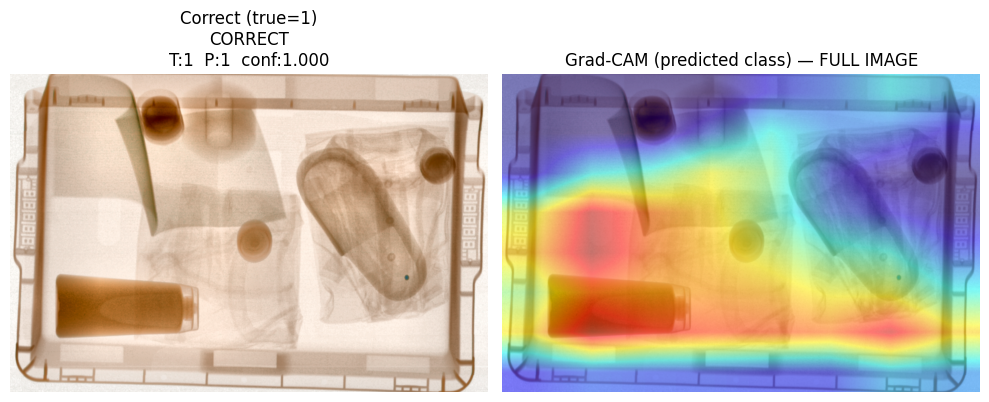


[Correct (true=1)] CORRECT
Path: images/val/stage2__2026-01-21_16-45-07-556_orig.png
True: 1 | Pred: 1 | Conf: 1.000

[Wrong   (true=0)] No sample found.

[Wrong   (true=1)] No sample found.


In [14]:
# ============================================================
# Grad-CAM EVAL (VAL): show ONLY 1 image of each class
#   - 1 correct sample for class 0
#   - 1 correct sample for class 1
#   - 1 wrong sample where true=0
#   - 1 wrong sample where true=1
# ============================================================

import sys
sys.path.append("../..")
from src.xraygen.explain.gradcam import GradCAM

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
import cv2

model = model.to(device).eval()

# -------------------------
# Choose target layer for Grad-CAM:
# use LAST conv layer in model.features
# -------------------------
conv_layers = [l for l in model.features if isinstance(l, torch.nn.Conv2d)]
assert len(conv_layers) > 0, "No Conv2d found in model.features"
target_layer = conv_layers[-1]
print("Grad-CAM target layer:", target_layer)

# -------------------------
# Helper: overlay heatmap
# -------------------------
def overlay_heatmap(base_img_pil: Image.Image, heatmap01: np.ndarray, alpha=0.5):
    base_rgb = np.array(base_img_pil.convert("RGB"))
    heatmap = cv2.resize(heatmap01, (base_rgb.shape[1], base_rgb.shape[0]))
    heatmap = np.clip(heatmap, 0, 1)
    heatmap_u8 = np.uint8(255 * heatmap)

    heatmap_bgr = cv2.applyColorMap(heatmap_u8, cv2.COLORMAP_JET)
    base_bgr = cv2.cvtColor(base_rgb, cv2.COLOR_RGB2BGR)
    overlay_bgr = cv2.addWeighted(base_bgr, 1 - alpha, heatmap_bgr, alpha, 0)
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)
    return overlay_rgb

# -------------------------
# Run model on val_loader to collect per-sample info
# -------------------------
samples = []  # list of dicts

with torch.no_grad():
    for imgs, y, paths in val_loader:
        imgs = imgs.to(device)
        y = y.to(device)

        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1)
        conf = probs.max(dim=1).values

        for i in range(len(paths)):
            samples.append({
                "path": paths[i],
                "true": int(y[i].item()),
                "pred": int(pred[i].item()),
                "conf": float(conf[i].item()),
            })

print("Val samples collected:", len(samples))

# -------------------------
# Pick ONLY 1 image of each:
#   correct_true0, correct_true1, wrong_true0, wrong_true1
# Prefer HIGH confidence for wrong (to inspect failures)
# Prefer HIGH confidence for correct (to inspect what it learned)
# -------------------------
def pick_one(filter_fn, prefer="high_conf"):
    cand = [s for s in samples if filter_fn(s)]
    if not cand:
        return None
    if prefer == "high_conf":
        cand.sort(key=lambda x: x["conf"], reverse=True)
    elif prefer == "low_conf":
        cand.sort(key=lambda x: x["conf"])
    return cand[0]

picked = {
    "correct_true0": pick_one(lambda s: s["true"] == 0 and s["pred"] == 0, prefer="high_conf"),
    "correct_true1": pick_one(lambda s: s["true"] == 1 and s["pred"] == 1, prefer="high_conf"),
    "wrong_true0"  : pick_one(lambda s: s["true"] == 0 and s["pred"] != 0, prefer="high_conf"),
    "wrong_true1"  : pick_one(lambda s: s["true"] == 1 and s["pred"] != 1, prefer="high_conf"),
}

print("\nPicked samples:")
for k, v in picked.items():
    print(k, "->", v)

# -------------------------
# Grad-CAM visualize a single sample
#   CAM target = predicted class (what model used to decide)
# -------------------------
gradcam = GradCAM(model, target_layer)

def show_one(tag, sample):
    if sample is None:
        print(f"\n[{tag}] No sample found.")
        return

    rel_path = sample["path"]
    true_y   = sample["true"]
    pred_y   = sample["pred"]
    conf     = sample["conf"]

    img_path = PROCESSED_ROOT / rel_path
    if not img_path.exists():
        print(f"\n[{tag}] Missing file:", img_path)
        return

    # Load FULL image (no crop)
    img_full = Image.open(img_path).convert("RGB")

    # Tensor uses FULL image too (same normalize pipeline)
    x = val_transform(img_full).unsqueeze(0).to(device)

    # Grad-CAM for predicted class
    heatmap = gradcam(x, target_class=int(pred_y))

    # Overlay heatmap on FULL image
    overlay = overlay_heatmap(img_full, heatmap, alpha=0.5)

    is_correct = (true_y == pred_y)
    verdict = "CORRECT" if is_correct else "WRONG"

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_full)
    plt.axis("off")
    plt.title(f"{tag}\n{verdict}\nT:{true_y}  P:{pred_y}  conf:{conf:.3f}")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Grad-CAM (predicted class) — FULL IMAGE")

    plt.tight_layout()
    plt.show()

    print(f"\n[{tag}] {verdict}")
    print("Path:", rel_path)
    print("True:", true_y, "| Pred:", pred_y, "| Conf:", f"{conf:.3f}")


# -------------------------
# Show ONLY 1 image per class bucket (4 total max)
# -------------------------
show_one("Correct (true=0)", picked["correct_true0"])
show_one("Correct (true=1)", picked["correct_true1"])
show_one("Wrong   (true=0)", picked["wrong_true0"])
show_one("Wrong   (true=1)", picked["wrong_true1"])

# cleanup hooks (important to avoid collisions later)
if hasattr(gradcam, "remove"):
    gradcam.remove()
else:
    try:
        target_layer._forward_hooks.clear()
        target_layer._backward_hooks.clear()
        target_layer._backward_pre_hooks.clear()
    except Exception:
        pass



Picked samples:
correct_true0 -> {'path': 'images/val/stage3__2026-01-22_15-56-11-837_orig.png', 'true': 0, 'pred': 0, 'conf': 0.9999997615814209}
correct_true1 -> {'path': 'images/val/stage2__2026-01-21_16-45-07-556_orig.png', 'true': 1, 'pred': 1, 'conf': 0.9999905824661255}
wrong_true0 -> None
wrong_true1 -> None
Total Conv2d layers: 6

[Correct (true=0)] CORRECT | T=0 P=0 conf=1.000 | images/val/stage3__2026-01-22_15-56-11-837_orig.png


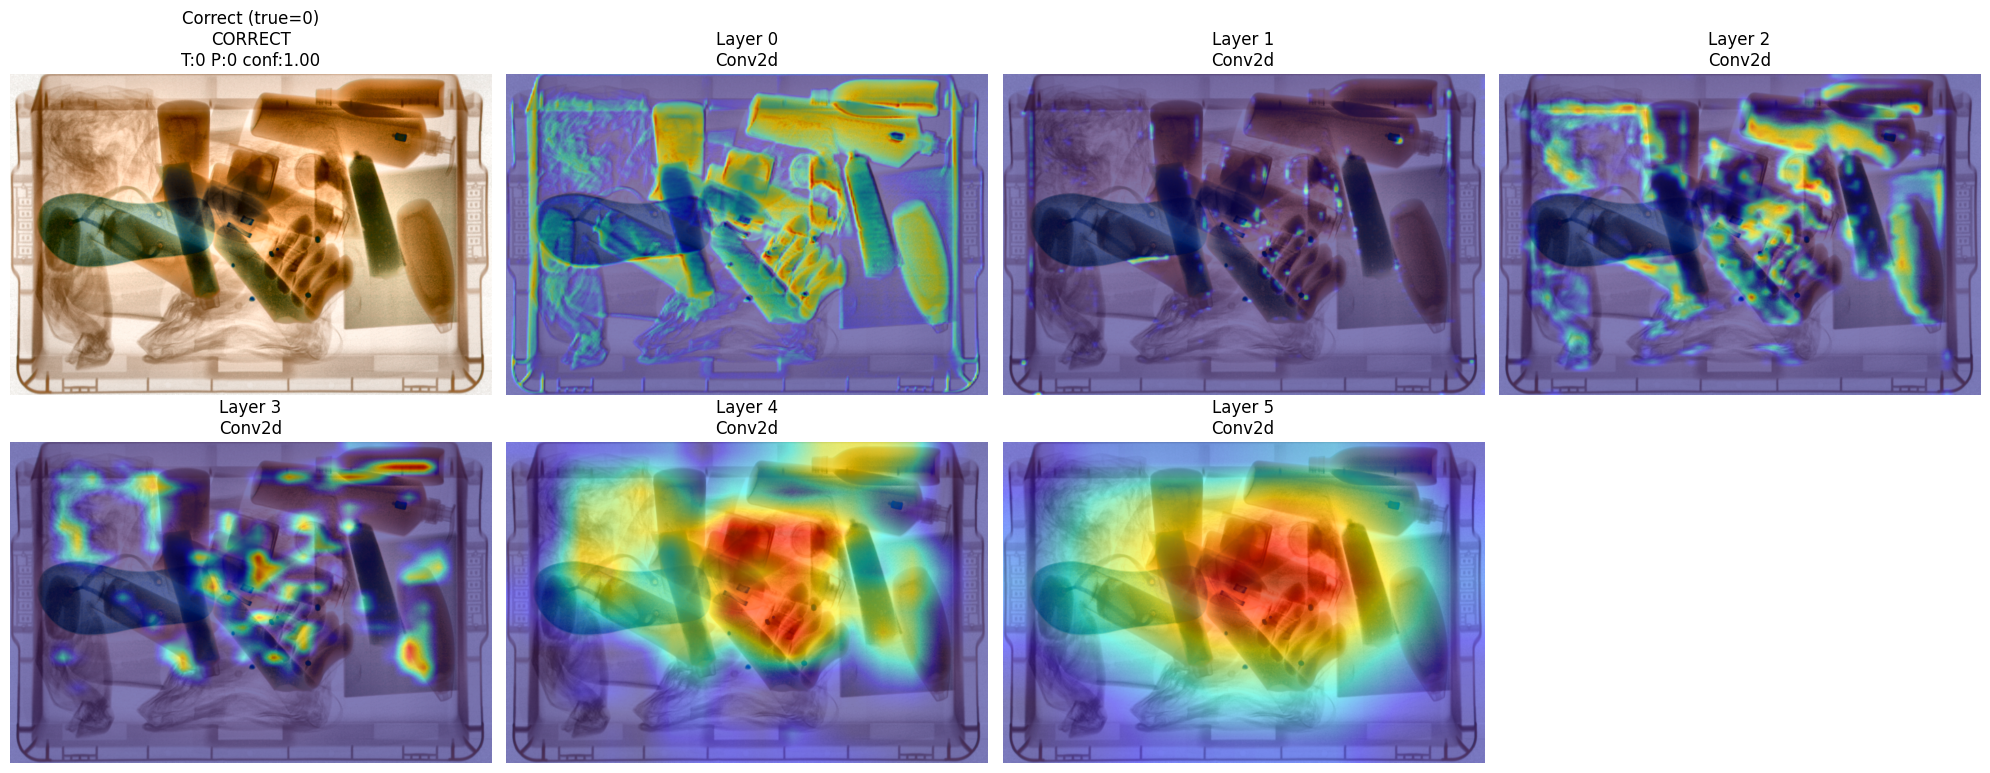


[Correct (true=1)] CORRECT | T=1 P=1 conf=1.000 | images/val/stage2__2026-01-21_16-45-07-556_orig.png


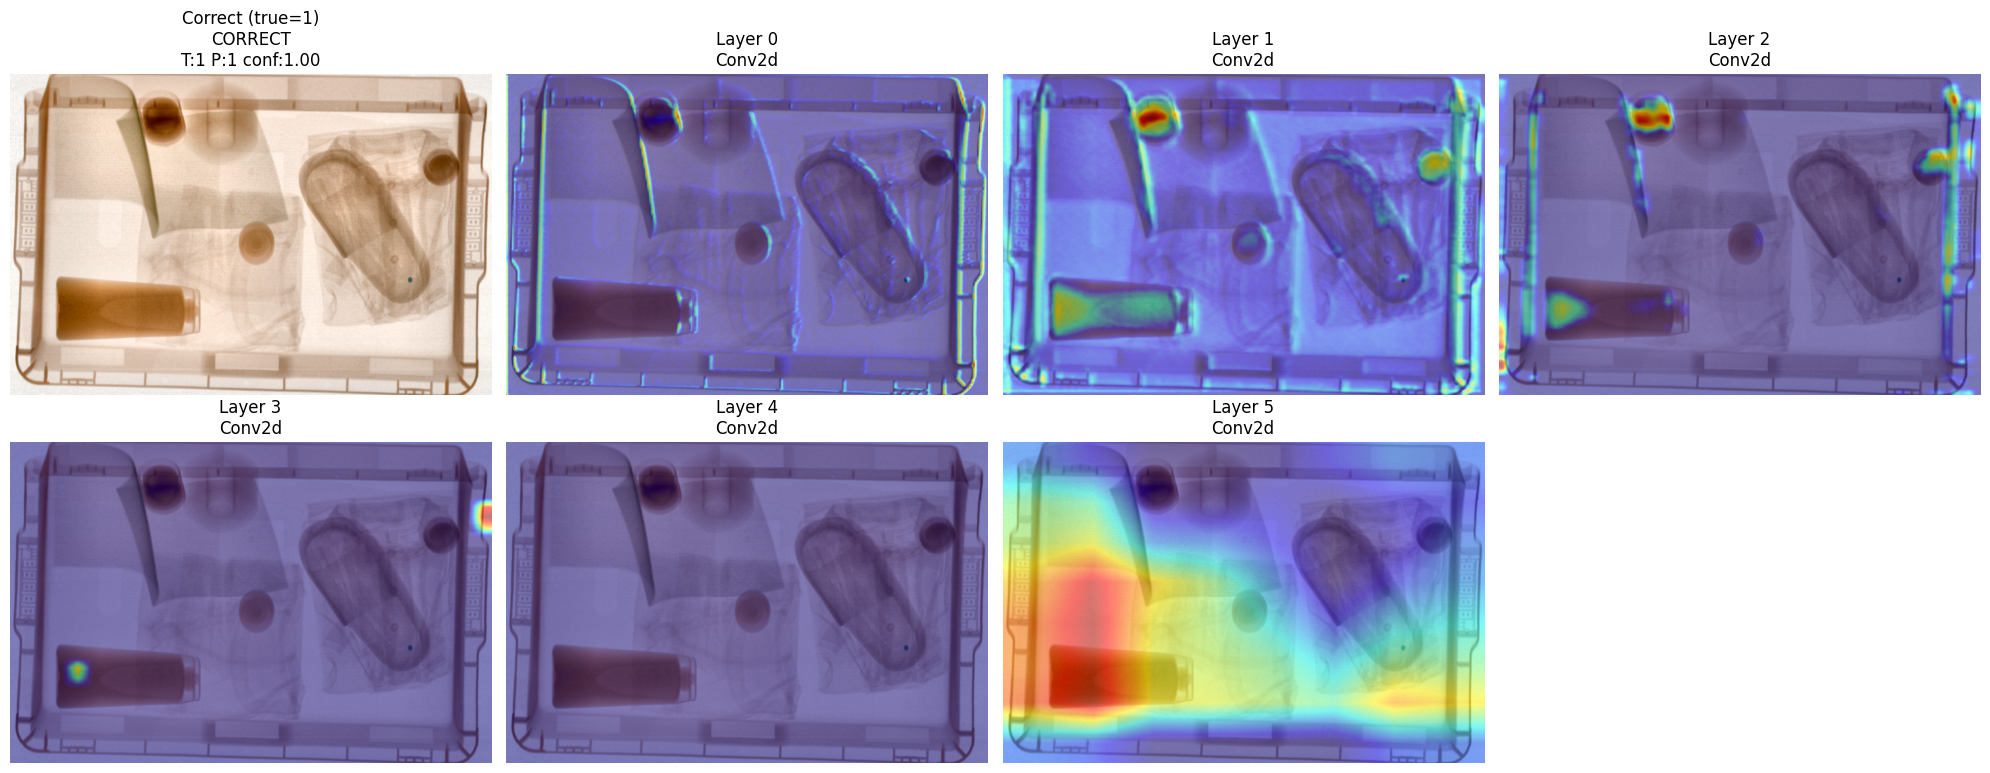


[Wrong   (true=0)] No sample found.

[Wrong   (true=1)] No sample found.
DONE


In [15]:
# ============================================================
# Grad-CAM EVAL (FULL IMAGE) — show ALL conv layers
#   - picks only 1 sample each:
#       correct true=0, correct true=1, wrong true=0, wrong true=1
#   - for EACH sample: loops through ALL Conv2d layers and shows CAM
#   - CAM computed on FULL image transform (no crop)
# ============================================================

import sys
sys.path.append("../..")
from src.xraygen.explain.gradcam import GradCAM

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
import torchvision.transforms as T
import cv2

model = model.to(device).eval()

# -------------------------
# FULL-IMAGE transform for CAM
# (no crop; you can keep aspect by letterbox if you want later)
# -------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

cam_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),   # FULL image resized (no CenterCrop)
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# -------------------------
# helper: overlay heatmap on FULL image
# -------------------------
def overlay_heatmap(base_img_pil: Image.Image, heatmap01: np.ndarray, alpha=0.5):
    base_rgb = np.array(base_img_pil.convert("RGB"))
    heatmap = cv2.resize(heatmap01, (base_rgb.shape[1], base_rgb.shape[0]))
    heatmap = np.clip(heatmap, 0, 1)
    heatmap_u8 = np.uint8(255 * heatmap)

    heatmap_bgr = cv2.applyColorMap(heatmap_u8, cv2.COLORMAP_JET)
    base_bgr = cv2.cvtColor(base_rgb, cv2.COLOR_RGB2BGR)
    overlay_bgr = cv2.addWeighted(base_bgr, 1 - alpha, heatmap_bgr, alpha, 0)
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)
    return overlay_rgb

# -------------------------
# collect preds on val (so we can pick 1 example each bucket)
# -------------------------
samples = []
with torch.no_grad():
    for imgs, y, paths in val_loader:
        imgs = imgs.to(device)
        y = y.to(device)

        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1)
        conf = probs.max(dim=1).values

        for i in range(len(paths)):
            samples.append({
                "path": paths[i],
                "true": int(y[i].item()),
                "pred": int(pred[i].item()),
                "conf": float(conf[i].item()),
            })

def pick_one(filter_fn, prefer="high_conf"):
    cand = [s for s in samples if filter_fn(s)]
    if not cand:
        return None
    cand.sort(key=lambda x: x["conf"], reverse=(prefer == "high_conf"))
    return cand[0]

picked = {
    "correct_true0": pick_one(lambda s: s["true"] == 0 and s["pred"] == 0, "high_conf"),
    "correct_true1": pick_one(lambda s: s["true"] == 1 and s["pred"] == 1, "high_conf"),
    "wrong_true0"  : pick_one(lambda s: s["true"] == 0 and s["pred"] != 0, "high_conf"),
    "wrong_true1"  : pick_one(lambda s: s["true"] == 1 and s["pred"] != 1, "high_conf"),
}

print("\nPicked samples:")
for k, v in picked.items():
    print(k, "->", v)

# -------------------------
# get ALL conv layers (in order)
# -------------------------
conv_layers = [l for l in model.features if isinstance(l, torch.nn.Conv2d)]
assert len(conv_layers) > 0, "No Conv2d found in model.features"
print("Total Conv2d layers:", len(conv_layers))

# -------------------------
# brute hook cleanup to avoid collisions between layers
# -------------------------
def cleanup_layer_hooks(layer):
    try:
        layer._forward_hooks.clear()
        layer._backward_hooks.clear()
        layer._backward_pre_hooks.clear()
    except Exception:
        pass

def cleanup_all_hooks():
    for l in conv_layers:
        cleanup_layer_hooks(l)

# -------------------------
# visualize ONE sample across ALL conv layers
# - shows: original full image + CAM overlays for every conv layer
# -------------------------
def show_sample_all_layers(tag: str, sample: dict, max_cols: int = 4):
    if sample is None:
        print(f"\n[{tag}] No sample found.")
        return

    rel_path = sample["path"]
    true_y   = sample["true"]
    pred_y   = sample["pred"]
    conf     = sample["conf"]

    img_path = PROCESSED_ROOT / rel_path
    if not img_path.exists():
        print(f"\n[{tag}] Missing file:", img_path)
        return

    img_full = Image.open(img_path).convert("RGB")

    # tensor for CAM is full image resized (no crop)
    x = cam_transform(img_full).unsqueeze(0).to(device)

    verdict = "CORRECT" if (true_y == pred_y) else "WRONG"
    print(f"\n[{tag}] {verdict} | T={true_y} P={pred_y} conf={conf:.3f} | {rel_path}")

    n_layers = len(conv_layers)
    cols = min(max_cols, n_layers + 1)  # +1 for original
    rows = int(np.ceil((n_layers + 1) / cols))

    plt.figure(figsize=(5 * cols, 4 * rows))

    # ---- panel 1: original full image
    plt.subplot(rows, cols, 1)
    plt.imshow(img_full)
    plt.axis("off")
    plt.title(f"{tag}\n{verdict}\nT:{true_y} P:{pred_y} conf:{conf:.2f}")

    # ---- panels 2.. : each conv layer CAM
    for i, layer in enumerate(conv_layers):
        cleanup_all_hooks()  # prevent "full vs regular hook" collisions
        gradcam = GradCAM(model, layer)

        heatmap = gradcam(x, target_class=int(pred_y))
        overlay = overlay_heatmap(img_full, heatmap, alpha=0.5)

        ax_idx = i + 2
        plt.subplot(rows, cols, ax_idx)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title(f"Layer {i}\n{layer.__class__.__name__}")

        # remove hooks (if your GradCAM class supports it)
        if hasattr(gradcam, "remove"):
            gradcam.remove()
        else:
            cleanup_layer_hooks(layer)

    plt.tight_layout()
    plt.show()

# -------------------------
# RUN: only 1 image each bucket (4 total)
# -------------------------
show_sample_all_layers("Correct (true=0)", picked["correct_true0"], max_cols=4)
show_sample_all_layers("Correct (true=1)", picked["correct_true1"], max_cols=4)
show_sample_all_layers("Wrong   (true=0)", picked["wrong_true0"], max_cols=4)
show_sample_all_layers("Wrong   (true=1)", picked["wrong_true1"], max_cols=4)

cleanup_all_hooks()
print("DONE")


Show "confident wrong" predicitons

Visualize a few wrong samples

Visual Model Predictions

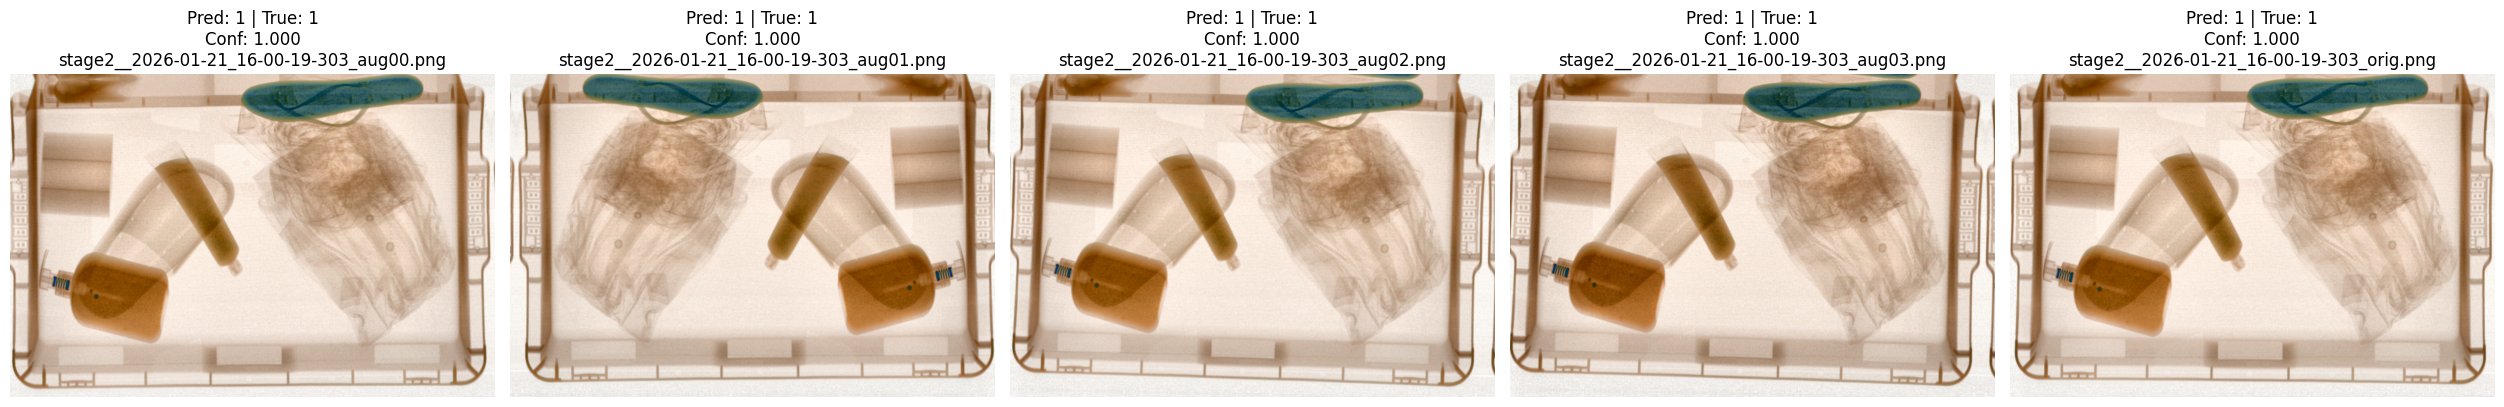

In [16]:
# Visualize predictions on validation set
import matplotlib.pyplot as plt
from PIL import Image

model.eval()
all_preds = []
all_labels = []
all_paths = []
all_confidences = []

with torch.no_grad():
    for imgs, labels, paths in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        confidences = probs.max(dim=1).values.cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_paths.extend(paths)
        all_confidences.extend(confidences)

# Display images with predictions and confidence
n = len(all_paths)
plt.figure(figsize=(5*n, 10))
for i in range(5):
    img = Image.open(PROCESSED_ROOT / all_paths[i]).convert("RGB")
    plt.subplot(1, n, i+1)
    plt.imshow(img)
    plt.title(f"Pred: {all_preds[i]} | True: {all_labels[i]}\nConf: {all_confidences[i]:.3f}\n{Path(all_paths[i]).name}")
    plt.axis("off")
plt.tight_layout()
plt.show()

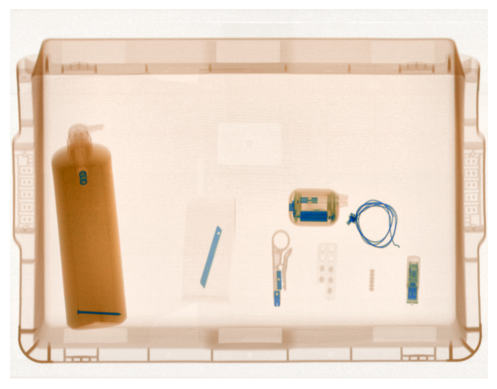

Predicted class: 1
Confidence     : 0.9999
Probabilities  : [9.1432768e-05 9.9990857e-01]
Val label distribution: [125 110]


In [17]:
# Predict on a single image

from PIL import Image
import matplotlib.pyplot as plt
import torch

# Enter the path to the image you want to predict
#image_path = "../../data/processed/Stage2/images/test/2026-01-21_15-45-07-582_aug03.png"

image_path = "../../data/test/processed/2026-01-15_16-18-00-471_color_clahe.png"

# =========================
# TRANSFORM for SINGLE IMAGE PREDICTION
# (must match validation preprocessing)
# =========================
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

if IMAGE_MODE == "rgb":
    predict_transform = T.Compose([
        T.Resize(int(IMAGE_SIZE * 1.10)),
        T.CenterCrop(IMAGE_SIZE),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
else:
    predict_transform = T.Compose([
        T.Resize(int(IMAGE_SIZE * 1.10)),
        T.CenterCrop(IMAGE_SIZE),
        T.ToTensor(),
    ])

if image_path:
    # Load and preprocess the image
    img = Image.open(image_path)

    if IMAGE_MODE == "gray":
        img = img.convert("L")
    else:
        img = img.convert("RGB")

    # Display the image
    plt.imshow(img, cmap="gray" if IMAGE_MODE == "gray" else None)
    plt.axis("off")
    plt.show()

    # Apply transform
    img_tensor = predict_transform(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs.max(dim=1).values.item()

    print(f"Predicted class: {pred_class}")
    print(f"Confidence     : {confidence:.4f}")
    print(f"Probabilities  : {probs.squeeze().cpu().numpy()}")

else:
    print("No path entered")

import numpy as np
print("Val label distribution:", np.bincount(val_ds.labels, minlength=2))




In [18]:
import json
from pathlib import Path

VAL_JSON = Path("../../data/labels/Stage1/combined/val.json")
data = json.load(open(VAL_JSON, "r"))
by_image = {it["image"].replace("\\","/"): it for it in data}

targets = [
 "images/val/2026-01-21_10-32-05-130_aug037.png",
 "images/val/2026-01-21_10-32-05-130_aug022.png",
 "images/val/2026-01-21_10-32-05-130_aug059.png",
]

for t in targets:
    it = by_image.get(t)
    print("\n", t)
    print(it)



from collections import Counter

def stage_counts(index_rows, split):
    c = Counter()
    for r in index_rows:
        if (r.get("split","").lower() == split):
            c[(r.get("stage","").lower())] += 1
    return c

print("Train stage counts:", stage_counts(index_rows, "train"))
print("Val stage counts  :", stage_counts(index_rows, "val"))

from collections import Counter
import json
from pathlib import Path

VAL_JSON = Path("../../data/labels/Stage1/combined/val.json")
labels = json.load(open(VAL_JSON, "r"))
label_map = {it["image"].replace("\\","/"): it for it in labels}

stage_label = Counter()
for r in index_rows:
    if r["split"].lower() != "val":
        continue
    fp = r["filepath"].replace("\\","/")
    st = r["stage"].lower()
    it = label_map.get(fp)
    if it is None:
        continue
    # your binary class rule
    y = 0 if (it["empty"]==1 and it["isolated_items"]==0 and it["no_contraband"]==1) else 1
    stage_label[(st, y)] += 1

print(stage_label)


 images/val/2026-01-21_10-32-05-130_aug037.png
{'image': 'images/val/2026-01-21_10-32-05-130_aug037.png', 'no_contraband': 1, 'isolated_items': 0, 'empty': 1}

 images/val/2026-01-21_10-32-05-130_aug022.png
{'image': 'images/val/2026-01-21_10-32-05-130_aug022.png', 'no_contraband': 1, 'isolated_items': 0, 'empty': 1}

 images/val/2026-01-21_10-32-05-130_aug059.png
{'image': 'images/val/2026-01-21_10-32-05-130_aug059.png', 'no_contraband': 1, 'isolated_items': 0, 'empty': 1}
Train stage counts: Counter({'stage3': 1070, 'stage2': 935})
Val stage counts  : Counter({'stage3': 125, 'stage2': 110})
Counter()


In [ ]:
# ============================================================
# Grad-CAM EXPORT (ALL CONV LAYERS) — batch-by-batch, no display
# - For each batch: compute preds once, then for EACH conv layer:
#   compute Grad-CAM per sample and save overlay to disk.
# - Saves: overlays/<layerXX>/<safe_rel_path>__T_P_conf.png
# - Writes a single CSV: gradcam_all_layers_summary.csv
# ============================================================

import os
import csv
import re
from pathlib import Path
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
import cv2

import sys
sys.path.append("../..")
from src.xraygen.explain.gradcam import GradCAM

# -------------------------
# Output config
# -------------------------
OUT_DIR = Path("./gradcam_export_val_all_layers")
OVERLAY_DIR = OUT_DIR / "overlays"
OUT_CSV = OUT_DIR / "gradcam_all_layers_summary.csv"

OUT_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# FULL image transform for CAM (no crop)
# MUST match your model's expected input normalization
# -------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

cam_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),   # full image resize
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# -------------------------
# Helpers
# -------------------------
def overlay_heatmap(base_img_pil: Image.Image, heatmap01: np.ndarray, alpha=0.5):
    base_rgb = np.array(base_img_pil.convert("RGB"))
    heatmap = cv2.resize(heatmap01, (base_rgb.shape[1], base_rgb.shape[0]))
    heatmap = np.clip(heatmap, 0, 1)
    heatmap_u8 = np.uint8(255 * heatmap)

    heatmap_bgr = cv2.applyColorMap(heatmap_u8, cv2.COLORMAP_JET)
    base_bgr = cv2.cvtColor(base_rgb, cv2.COLOR_RGB2BGR)
    overlay_bgr = cv2.addWeighted(base_bgr, 1 - alpha, heatmap_bgr, alpha, 0)
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)
    return overlay_rgb

def safe_name(s: str) -> str:
    s = s.replace("\\", "/")
    s = re.sub(r"[^a-zA-Z0-9._\-\/]+", "_", s)
    return s.replace("/", "__")

def cleanup_layer_hooks(layer):
    # brute cleanup (prevents hook collisions when you recreate GradCAM per layer)
    try:
        layer._forward_hooks.clear()
        layer._backward_hooks.clear()
        layer._backward_pre_hooks.clear()
    except Exception:
        pass

# -------------------------
# Get ALL conv layers (order)
# -------------------------
model = model.to(device).eval()
conv_layers = [l for l in model.features if isinstance(l, torch.nn.Conv2d)]
assert len(conv_layers) > 0, "No Conv2d found in model.features"
print("Total Conv2d layers:", len(conv_layers))

# Create subfolders per layer
for li in range(len(conv_layers)):
    (OVERLAY_DIR / f"layer_{li:02d}").mkdir(parents=True, exist_ok=True)

# -------------------------
# CSV setup
# -------------------------
fieldnames = [
    "split",
    "rel_path",
    "abs_path",
    "true",
    "pred",
    "conf",
    "layer_idx",
    "layer_name",
    "saved_overlay",
    "status",
]

rows_out = []

# -------------------------
# Export loop (batch-by-batch)
# -------------------------
n_total = 0
n_saved = 0

# We do prediction under no_grad(), but GradCAM needs gradients.
# So: get preds/conf under no_grad, then enable_grad for CAM part.
for batch_idx, (imgs, y, paths) in enumerate(val_loader):
    print(f"\nBatch {batch_idx+1}/{len(val_loader)} | bs={len(paths)}")

    # ---- 1) Predict once for the batch
    imgs = imgs.to(device)
    y = y.to(device)

    with torch.no_grad():
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1)
        conf = probs.max(dim=1).values

    # Move small metadata to CPU lists
    true_list = [int(v) for v in y.detach().cpu().tolist()]
    pred_list = [int(v) for v in pred.detach().cpu().tolist()]
    conf_list = [float(v) for v in conf.detach().cpu().tolist()]
    paths_list = list(paths)

    # ---- 2) For EACH conv layer, compute CAM per sample (low memory)
    for li, layer in enumerate(conv_layers):
        layer_name = layer.__class__.__name__
        print(f"  Layer {li}/{len(conv_layers)-1}: {layer_name}")

        # Ensure no old hooks interfere
        cleanup_layer_hooks(layer)

        # Create GradCAM for this layer
        gradcam = GradCAM(model, layer)

        # Enable gradients for CAM
        with torch.enable_grad():
            for i in range(len(paths_list)):
                rel_path = paths_list[i]
                true_y = true_list[i]
                pred_y = pred_list[i]
                conf_i = conf_list[i]
                img_path = PROCESSED_ROOT / rel_path

                n_total += 1

                if not img_path.exists():
                    rows_out.append({
                        "split": "val",
                        "rel_path": rel_path,
                        "abs_path": str(img_path),
                        "true": true_y,
                        "pred": pred_y,
                        "conf": conf_i,
                        "layer_idx": li,
                        "layer_name": layer_name,
                        "saved_overlay": "",
                        "status": "missing_file",
                    })
                    continue

                # Load FULL image (no crop)
                try:
                    img_full = Image.open(img_path).convert("RGB")
                except Exception as e:
                    rows_out.append({
                        "split": "val",
                        "rel_path": rel_path,
                        "abs_path": str(img_path),
                        "true": true_y,
                        "pred": pred_y,
                        "conf": conf_i,
                        "layer_idx": li,
                        "layer_name": layer_name,
                        "saved_overlay": "",
                        "status": f"load_error:{type(e).__name__}",
                    })
                    continue

                # Prepare tensor (full image)
                x = cam_transform(img_full).unsqueeze(0).to(device)

                # IMPORTANT: GradCAM does backward internally; clear grads to avoid accumulation
                model.zero_grad(set_to_none=True)

                # Compute heatmap for predicted class
                try:
                    heatmap = gradcam(x, target_class=pred_y)  # expects np (H,W) in [0,1]
                    overlay = overlay_heatmap(img_full, heatmap, alpha=0.5)
                except Exception as e:
                    rows_out.append({
                        "split": "val",
                        "rel_path": rel_path,
                        "abs_path": str(img_path),
                        "true": true_y,
                        "pred": pred_y,
                        "conf": conf_i,
                        "layer_idx": li,
                        "layer_name": layer_name,
                        "saved_overlay": "",
                        "status": f"gradcam_error:{type(e).__name__}",
                    })
                    continue

                # Save overlay
                base = safe_name(rel_path)
                out_name = f"{base}__T{true_y}_P{pred_y}_conf{conf_i:.3f}.png"
                out_path = OVERLAY_DIR / f"layer_{li:02d}" / out_name

                overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
                ok = cv2.imwrite(str(out_path), overlay_bgr)

                if ok:
                    n_saved += 1
                    rows_out.append({
                        "split": "val",
                        "rel_path": rel_path,
                        "abs_path": str(img_path),
                        "true": true_y,
                        "pred": pred_y,
                        "conf": conf_i,
                        "layer_idx": li,
                        "layer_name": layer_name,
                        "saved_overlay": str(out_path),
                        "status": "ok",
                    })
                else:
                    rows_out.append({
                        "split": "val",
                        "rel_path": rel_path,
                        "abs_path": str(img_path),
                        "true": true_y,
                        "pred": pred_y,
                        "conf": conf_i,
                        "layer_idx": li,
                        "layer_name": layer_name,
                        "saved_overlay": "",
                        "status": "save_failed",
                    })

        # remove hooks for this GradCAM to avoid collisions
        if hasattr(gradcam, "remove"):
            gradcam.remove()
        else:
            cleanup_layer_hooks(layer)

    # Optional: flush intermediate CSV every batch (so you don't lose progress if it crashes)
    # This is safer for long runs.
    with open(OUT_CSV, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(rows_out)

    print(f"Batch done. Running totals: total_rows={n_total}, saved={n_saved}, csv={OUT_CSV}")

print("\nDONE")
print(f"Total layer-rows processed: {n_total}")
print(f"Total overlays saved: {n_saved}")
print(f"Outputs in: {OUT_DIR}")
print(f"CSV: {OUT_CSV}")


Total Conv2d layers: 6

Batch 1/3 | bs=80
  Layer 0/5: Conv2d
  Layer 1/5: Conv2d
  Layer 2/5: Conv2d
  Layer 3/5: Conv2d
  Layer 4/5: Conv2d
  Layer 5/5: Conv2d
Batch done. Running totals: total_rows=480, saved=480, csv=gradcam_export_val_all_layers/gradcam_all_layers_summary.csv

Batch 2/3 | bs=80
  Layer 0/5: Conv2d
  Layer 1/5: Conv2d
  Layer 2/5: Conv2d
  Layer 3/5: Conv2d
  Layer 4/5: Conv2d
  Layer 5/5: Conv2d
Batch done. Running totals: total_rows=960, saved=960, csv=gradcam_export_val_all_layers/gradcam_all_layers_summary.csv

Batch 3/3 | bs=75
  Layer 0/5: Conv2d
  Layer 1/5: Conv2d
  Layer 2/5: Conv2d
  Layer 3/5: Conv2d
  Layer 4/5: Conv2d
  Layer 5/5: Conv2d
Batch done. Running totals: total_rows=1410, saved=1410, csv=gradcam_export_val_all_layers/gradcam_all_layers_summary.csv

DONE ✅
Total layer-rows processed: 1410
Total overlays saved: 1410
Outputs in: gradcam_export_val_all_layers
CSV: gradcam_export_val_all_layers/gradcam_all_layers_summary.csv


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import html

# =========================
# CONFIG
# =========================
OUT_DIR = Path("./gradcam_export_val_all_layers")  # folder you exported overlays into
CSV_PATH = OUT_DIR / "gradcam_all_layers_summary.csv"
HTML_ALL = OUT_DIR / "gallery_all.html"
HTML_WRONG = OUT_DIR / "gallery_wrong.html"
HTML_CONFW = OUT_DIR / "gallery_confwrong.html"

# How many images per page section (keeps browser smooth)
IMAGES_PER_CHUNK = 40

# For "confident wrong"
TOP_CONF_WRONG = 200  # top K images by confidence (wrong only)

assert CSV_PATH.exists(), f"CSV not found: {CSV_PATH}"

df = pd.read_csv(CSV_PATH)
df = df[df["status"] == "ok"].copy()

# Ensure expected columns
needed = ["rel_path", "true", "pred", "conf", "layer_idx", "saved_overlay"]
for c in needed:
    assert c in df.columns, f"Missing column: {c}"

# Normalize paths for HTML (relative paths recommended)
# Make saved_overlay relative to OUT_DIR so HTML works if moved together
def rel_to_outdir(p: str) -> str:
    pth = Path(p)
    try:
        return str(pth.relative_to(OUT_DIR))
    except Exception:
        # if absolute or different root, fallback: use as-is
        return str(pth)

df["overlay_rel"] = df["saved_overlay"].apply(rel_to_outdir)

# Group by image
g = df.groupby("rel_path")

# Create an image-level summary table
img_summary = g.agg(
    true=("true", "first"),
    pred=("pred", "first"),
    conf=("conf", "max"),          # max conf across layers (they should be same anyway)
    n_layers=("layer_idx", "nunique"),
).reset_index()

img_summary["correct"] = img_summary["true"] == img_summary["pred"]

# Sort images: wrong first, then by confidence desc
img_summary = img_summary.sort_values(["correct", "conf"], ascending=[True, False]).reset_index(drop=True)

# ================
# HTML helpers
# ================
CSS = """
<style>
body { font-family: ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Arial; margin: 16px; background:#0b0f14; color:#e8eef6; }
h1 { font-size: 20px; margin: 0 0 12px 0; }
.controls { display:flex; gap:12px; flex-wrap:wrap; margin: 12px 0 18px 0; }
.badge { display:inline-block; padding: 2px 8px; border-radius: 999px; font-size: 12px; }
.badge.ok { background:#123d2a; color:#b8ffd8; border:1px solid #1e6a45; }
.badge.bad { background:#3b1a1a; color:#ffd1d1; border:1px solid #7b2a2a; }
.badge.info { background:#102238; color:#c9e2ff; border:1px solid #1a3b63; }

.section { border:1px solid #1c2633; background:#0f1620; border-radius: 14px; padding: 12px; margin: 12px 0; }
.section-header { display:flex; justify-content:space-between; align-items:flex-start; gap:12px; flex-wrap:wrap; }
.title { font-size: 14px; line-height: 1.3; }
.meta { font-size: 12px; opacity: 0.9; }
.grid { display:grid; grid-template-columns: repeat(auto-fill, minmax(240px, 1fr)); gap: 10px; margin-top: 12px; }
.card { border:1px solid #243245; border-radius: 12px; overflow:hidden; background:#0b0f14; }
.card img { width:100%; display:block; }
.card .cap { padding: 8px 10px; font-size: 12px; border-top:1px solid #243245; color:#d6e3f2; }
.small { font-size: 12px; opacity: 0.9; }
hr { border: none; border-top: 1px solid #1c2633; margin: 14px 0; }

#topbtn {
  position: fixed; right: 14px; bottom: 14px;
  background: #1a3b63; color: #e8eef6; border:1px solid #2a5c98;
  padding: 10px 12px; border-radius: 12px; cursor: pointer;
  font-size: 12px; opacity: 0.85;
}
#topbtn:hover { opacity: 1.0; }

input[type="text"]{
  background:#0b0f14; border:1px solid #243245; color:#e8eef6;
  padding: 8px 10px; border-radius: 10px; min-width: 320px;
}
button{
  background:#102238; border:1px solid #1a3b63; color:#e8eef6;
  padding: 8px 10px; border-radius: 10px; cursor:pointer;
}
button:hover{ border-color:#2a5c98; }
.hidden{ display:none; }
</style>
"""

JS = """
<script>
function filterByText() {
  const q = document.getElementById("search").value.toLowerCase();
  const secs = document.querySelectorAll(".section");
  secs.forEach(sec => {
    const key = sec.getAttribute("data-key") || "";
    if (key.toLowerCase().includes(q)) sec.classList.remove("hidden");
    else sec.classList.add("hidden");
  });
}
function scrollTopNow() { window.scrollTo({top:0, behavior:'smooth'}); }
</script>
"""

def esc(s): 
    return html.escape(str(s))

def build_gallery(img_rows, title, out_path: Path):
    parts = []
    parts.append("<html><head><meta charset='utf-8'>")
    parts.append(f"<title>{esc(title)}</title>")
    parts.append(CSS)
    parts.append("</head><body>")
    parts.append(f"<h1>{esc(title)}</h1>")

    parts.append("<div class='controls'>")
    parts.append(f"<span class='badge info'>Images: {len(img_rows)}</span>")
    parts.append(f"<span class='badge info'>Overlays: {len(df)}</span>")
    parts.append("<input id='search' type='text' placeholder='Search by filename / rel_path...' oninput='filterByText()'/>")
    parts.append("<button onclick='filterByText()'>Filter</button>")
    parts.append("</div>")

    # Chunking: adds separators so browser doesn't choke on giant DOM
    for chunk_start in range(0, len(img_rows), IMAGES_PER_CHUNK):
        chunk = img_rows.iloc[chunk_start:chunk_start + IMAGES_PER_CHUNK]
        parts.append(f"<hr><div class='small'>Chunk {chunk_start//IMAGES_PER_CHUNK + 1} "
                     f"({chunk_start+1}–{min(chunk_start+IMAGES_PER_CHUNK, len(img_rows))})</div>")

        for _, row in chunk.iterrows():
            rel_path = row["rel_path"]
            true = int(row["true"])
            pred = int(row["pred"])
            conf = float(row["conf"])
            correct = bool(row["correct"])
            verdict_badge = "ok" if correct else "bad"
            verdict_txt = "CORRECT" if correct else "WRONG"

            # all layers for this image
            sub = df[df["rel_path"] == rel_path].sort_values("layer_idx")

            # header
            parts.append(f"<div class='section' data-key='{esc(rel_path)}'>")
            parts.append("<div class='section-header'>")
            parts.append("<div class='title'>"
                         f"<span class='badge {verdict_badge}'>{verdict_txt}</span> "
                         f"<b>{esc(Path(rel_path).name)}</b><br>"
                         f"<span class='meta'>{esc(rel_path)}</span>"
                         "</div>")
            parts.append("<div class='meta'>"
                         f"T:{true} &nbsp; P:{pred} &nbsp; conf:{conf:.4f}<br>"
                         f"Layers:{int(row['n_layers'])}"
                         "</div>")
            parts.append("</div>")  # header

            parts.append("<div class='grid'>")
            for _, r2 in sub.iterrows():
                layer_idx = int(r2["layer_idx"])
                img_src = esc(r2["overlay_rel"])
                cap = esc(f"Layer {layer_idx:02d} | T{true} P{pred} | conf {conf:.3f}")
                parts.append("<div class='card'>")
                parts.append(f"<img loading='lazy' src='{img_src}'/>")
                parts.append(f"<div class='cap'>{cap}</div>")
                parts.append("</div>")
            parts.append("</div>")  # grid
            parts.append("</div>")  # section

    parts.append("<button id='topbtn' onclick='scrollTopNow()'>⬆ Top</button>")
    parts.append(JS)
    parts.append("</body></html>")

    out_path.write_text("\n".join(parts), encoding="utf-8")
    print(" Wrote:", out_path)

# =========================
# Build galleries
# =========================

# 1) All images
build_gallery(img_summary, "Grad-CAM Gallery — ALL images × ALL layers", HTML_ALL)

# 2) Wrong only
img_wrong = img_summary[~img_summary["correct"]].copy()
build_gallery(img_wrong, "Grad-CAM Gallery — WRONG images × ALL layers", HTML_WRONG)

# 3) Top confident wrong only
img_confwrong = img_wrong.sort_values("conf", ascending=False).head(TOP_CONF_WRONG).copy()
build_gallery(img_confwrong, f"Grad-CAM Gallery — TOP {TOP_CONF_WRONG} confident WRONG × ALL layers", HTML_CONFW)

print("\nOpen these in browser:")
print(" -", HTML_ALL)
print(" -", HTML_WRONG)
print(" -", HTML_CONFW)


✅ Wrote: gradcam_export_val_all_layers/gallery_all.html
✅ Wrote: gradcam_export_val_all_layers/gallery_wrong.html
✅ Wrote: gradcam_export_val_all_layers/gallery_confwrong.html

Open these in browser:
 - gradcam_export_val_all_layers/gallery_all.html
 - gradcam_export_val_all_layers/gallery_wrong.html
 - gradcam_export_val_all_layers/gallery_confwrong.html


Use GradCam to evaluate